## Capítulo 1: Análise Exploratória Inicial

In [ ]:
import duckdb

# Quantidade total de linhas, quantidade de colunas, data mínima e data máxima da coluna "sale_date"
duckdb.sql("""
SELECT
    COUNT(*) AS quantidade_linhas,
    6 AS quantidade_colunas,
    MIN(COALESCE(TRY_STRPTIME(sale_date, '%Y-%m-%d'), TRY_STRPTIME(sale_date, '%d-%m-%Y')))::DATE AS data_minima,
    MAX(COALESCE(TRY_STRPTIME(sale_date, '%Y-%m-%d'), TRY_STRPTIME(sale_date, '%d-%m-%Y')))::DATE AS data_maxima
FROM read_csv_auto('datasets/vendas_2023_2024.csv');
""").df()

,quantidade_linhas,quantidade_colunas,data_minima,data_maxima
0,9895,6,2023-01-01,2024-12-31


In [ ]:
# Valor mínimo, valor máximo e valor médio da coluna "total"
duckdb.sql("""
SELECT
    MIN(total) AS valor_minimo,
    MAX(total) AS valor_maximo,
    ROUND(AVG(total), 2) AS valor_medio
FROM read_csv_auto('datasets/vendas_2023_2024.csv');
""").df()

,valor_minimo,valor_maximo,valor_medio
0,294.5,2222973.0,263797.83


In [ ]:
# Quantidade de valores nulos em cada coluna e quantidade de valores negativos na coluna "total"
duckdb.sql("""
SELECT
    SUM(CASE WHEN id IS NULL THEN 1 ELSE 0 END) AS nulos_id,
    SUM(CASE WHEN id_client IS NULL THEN 1 ELSE 0 END) AS nulos_id_client,
    SUM(CASE WHEN id_product IS NULL THEN 1 ELSE 0 END) AS nulos_id_product,
    SUM(CASE WHEN qtd IS NULL THEN 1 ELSE 0 END) AS nulos_qtd,
    SUM(CASE WHEN total IS NULL THEN 1 ELSE 0 END) AS nulos_total,
    SUM(CASE WHEN sale_date IS NULL THEN 1 ELSE 0 END) AS nulos_sale_date,
    SUM(CASE WHEN total < 0 THEN 1 ELSE 0 END) AS totais_negativos
FROM read_csv_auto('datasets/vendas_2023_2024.csv');
""").df()


,nulos_id,nulos_id_client,nulos_id_product,nulos_qtd,nulos_total,nulos_sale_date,totais_negativos
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
import pandas as pd 

# Carregando o dataset com pandas 
df_vendas = pd.read_csv('datasets/vendas_2023_2024.csv')
df_vendas

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,15-09-2024
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12
...,...,...,...,...,...,...
9890,9995,30,139,6,8549.00,11-03-2023
9891,9996,9,111,7,28497.15,17-09-2023
9892,9997,38,123,2,5276.30,20-06-2023
9893,9998,33,97,6,771409.50,23-10-2024


In [39]:
# Parte 1 - Visão geral do dataset
quantidade_linhas, quantidade_colunas = df_vendas.shape

# Tratamento para leitura das datas
datas_parseadas = pd.to_datetime(df_vendas['sale_date'], format='mixed', dayfirst=False, errors='coerce')
data_minima = datas_parseadas.min().strftime('%d/%m/%Y')
data_maxima = datas_parseadas.max().strftime('%d/%m/%Y')

print('----- Visão Geral do Dataset -----')
print(f'Quantidade de linhas: {quantidade_linhas}')
print(f'Quantidade de colunas: {quantidade_colunas}')
print(f'Data mínima: {data_minima}')
print(f'Data máxima: {data_maxima}')


----- Visão Geral do Dataset -----
Quantidade de linhas: 9895
Quantidade de colunas: 6
Data mínima: 01/01/2023
Data máxima: 31/12/2024


In [40]:
# Parte 2 - Análise de valores numéricos
valor_minimo = df_vendas['total'].min()
valor_maximo = df_vendas['total'].max()
valor_medio = df_vendas['total'].mean()

print('----- Análise de Valores Numéricos -----')
print(f'Valor mínimo: {valor_minimo:.2f}')
print(f'Valor máximo: {valor_maximo:.2f}')
print(f'Valor médio: {valor_medio:.2f}')

----- Análise de Valores Numéricos -----
Valor mínimo: 294.50
Valor máximo: 2222973.00
Valor médio: 263797.83


In [41]:
# Análise de valores nulos ou negativos 
print(f"Valores Nulos:\n{df_vendas.isnull().sum()}\n")
print(f"Vendas com valor negativo: {(df_vendas['total'] < 0).sum()}")

Valores Nulos:
id            0
id_client     0
id_product    0
qtd           0
total         0
sale_date     0
dtype: int64

Vendas com valor negativo: 0


#### Diagnóstico 

Com base nesta exploração primária, a resposta direta é: Não podemos confiar nestes dados brutos para análises avançadas ou previsões de IA sem um tratamento prévio rigoroso. O dataset apresenta **9.895 registros** no período de **01/01/2023 a 31/12/2024** e, embora não possua valores nulos evidentes (`NaN`) ou faturamentos negativos, esconde problemas estruturais.

- **Outliers:** A média de faturamento por transação (R$ 263 mil) é puxada por anomalias extremas, com um valor máximo atingindo **R$ 2,2 milhões**. Isso pode indicar vendas B2B massivas, a venda de embarcações inteiras misturadas com peças, ou graves erros sistêmicos de digitação. Modelar IA com esses picos destruirá a acurácia de qualquer previsão de demanda.
- **Datas:** As datas de venda estão corrompidas, misturando os padrões `YYYY-MM-DD` e `DD-MM-YYYY`. Isso inviabiliza fechamentos de caixa diários confiáveis e destrói o conceito de sazonalidade necessário para a IA.

**Conclusão:** O dataset exige uma camada de Engenharia de Dados (padronização de tipos e tratamento de anomalias) antes de seguir para a construção de modelos de Machine Learning.

-------------------------------------------------------------------------------------------------------------------------

## Capítulo 2: Produtos

In [42]:
import pandas as pd 

# Carregando o dataset 
df_produtos = pd.read_csv('datasets/produtos_raw.csv')
df_produtos

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz
...,...,...,...,...
152,Corrente Delta Vox Ion,R$ 495.98,146,ancoragem
153,Corrente Danforth Force Leviathan Impulse,R$ 3030.08,147,Ancoraguem
154,Âncora Delta Force Barracuda Mako,R$ 4785.56,148,Ancorajem
155,Cabo de Nylon Bruce Core,R$ 1163.62,149,Ancoragem


In [43]:
# Parte 1 - Padronizando os nomes das categorias de produtos

# Remove todos os espaços e converte para minúsculo
df_produtos['actual_category'] = df_produtos['actual_category'].astype(str).str.lower().str.replace(' ', '', regex=False)

produtos_convertidos = df_produtos['actual_category'].unique()
produtos_convertidos

array(['eletronicos', 'eletrônicos', 'eletrunicos', 'eletronicoz',
       'eletroniscos', 'propulsao', 'propulção', 'prop', 'propulssão',
       'propulsão', 'propução', 'propulçao', 'propulsam', 'ancoragem',
       'encoragem', 'ancoraguem', 'ancorajm', 'ancorajem', 'encoragi',
       'ancorajen', 'ancoragen'], dtype=object)

In [44]:
variantes_categoria = {
    'eletrônicos': ['eletronicos', 'eletrônicos', 'eletrunicos', 'eletronicoz', 'eletroniscos'],
    'propulsão': ['propulsao', 'propulção', 'prop', 'propulssão', 'propulsão', 'propulçao', 'propução', 'propulsam'],
    'ancoragem': ['ancoragem', 'encoragem', 'ancoraguem', 'ancorajm', 'ancorajem', 'ancorajen']
}

# Mapeamento de categorias para padronização
def mapear_categoria(categoria): 

    for categoria_padronizada, variantes in variantes_categoria.items():
        if categoria in variantes:
            return categoria_padronizada
    
    return categoria 

# Aplicando o função em toda a coluna 
df_produtos['categoria_padronizada'] = df_produtos['actual_category'].apply(mapear_categoria)
df_produtos[['actual_category', 'categoria_padronizada']]


,actual_category,categoria_padronizada
0,eletronicos,eletrônicos
1,eletronicos,eletrônicos
2,eletrônicos,eletrônicos
3,eletrunicos,eletrônicos
4,eletronicoz,eletrônicos
...,...,...
152,ancoragem,ancoragem
153,ancoraguem,ancoragem
154,ancorajem,ancoragem
155,ancoragem,ancoragem


In [45]:
# Parte 2 - Convertendo os valores para tipo numérico
df_produtos.dtypes

# price convertido para float, removendo o símbolo de moeda e convertendo a vírgula para ponto
df_produtos['price'] = df_produtos['price'].str.replace('R$ ', '', regex=False).astype(float)

In [46]:
# Parte 3 - Removendo duplicatas
df_produtos = df_produtos.drop_duplicates()
df_produtos = df_produtos.drop_duplicates(subset=['code'])

In [47]:
print('----- Produtos -----')
print(f"\nCategorias únicas: {df_produtos['actual_category'].unique()}\n")
print(f"Tipos de dados:\n{df_produtos.dtypes}\n")
print(f"Total de produtos únicos: {len(df_produtos)}")

----- Produtos -----

Categorias únicas: ['eletronicos' 'eletrônicos' 'eletrunicos' 'eletronicoz' 'eletroniscos'
 'propulsao' 'propulção' 'prop' 'propulssão' 'propulsão' 'propulçao'
 'propução' 'propulsam' 'ancoragem' 'encoragem' 'ancoraguem' 'ancorajm'
 'ancorajem' 'ancorajen']

Tipos de dados:
name                      object
price                    float64
code                       int64
actual_category           object
categoria_padronizada     object
dtype: object

Total de produtos únicos: 150


## Capítulo 3: Custos de Importação

In [48]:
# Acessando o arquivo JSON para leitura 
import pandas as pd
import json 

with open('datasets/custos_importacao.json', 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

# Criando o DataFrame a partir do JSON, normalizando os dados aninhados
df_custos = pd.json_normalize(dados_json, record_path=['historic_data'], meta=['product_id', 'product_name', 'category'])

df_custos['product_id'] = df_custos['product_id'].astype(int)
df_custos['product_name'] = df_custos['product_name'].astype(str)
df_custos['category'] = df_custos['category'].astype(str)
df_custos['start_date'] = pd.to_datetime(df_custos['start_date'], dayfirst=True, errors='coerce').dt.date
df_custos['usd_price'] = df_custos['usd_price'].astype(float)

df_custos.head()

,start_date,usd_price,product_id,product_name,category
0,2016-08-10,10583.63,1,Transponder AIS Maré Magnum,eletrônicos
1,2018-06-15,8778.36,1,Transponder AIS Maré Magnum,eletrônicos
2,2018-09-25,8023.87,1,Transponder AIS Maré Magnum,eletrônicos
3,2019-03-19,8772.78,1,Transponder AIS Maré Magnum,eletrônicos
4,2020-01-17,7918.18,1,Transponder AIS Maré Magnum,eletrônicos


In [49]:
print(f'Total de entradas após a normalização: {len(df_custos)}')

Total de entradas após a normalização: 1260


## Capítulo 4 - Dados Públicos

In [50]:
# Parte 1 - Importando as bibliotecas
import json
import pandas as pd
import requests
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# Parte 1 - Carregando o dataset de vendas
df_vendas = pd.read_csv('datasets/vendas_2023_2024.csv')

# Tratamento para leitura das datas
df_vendas['sale_date'] = pd.to_datetime(
    df_vendas['sale_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

df_vendas.head()


,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [52]:
# Parte 1 - Carregando o arquivo JSON de custos
with open('datasets/custos_importacao.json', 'r', encoding='utf-8') as f:
    dados_json = json.load(f)

df_custos = pd.json_normalize(
    dados_json,
    record_path=['historic_data'],
    meta=['product_id', 'product_name', 'category']
)

df_custos = df_custos[['product_id', 'product_name', 'category', 'start_date', 'usd_price']].copy()
df_custos['product_id'] = df_custos['product_id'].astype(int)
df_custos['product_name'] = df_custos['product_name'].astype(str)
df_custos['category'] = df_custos['category'].astype(str)
df_custos['start_date'] = pd.to_datetime(df_custos['start_date'], dayfirst=True, errors='coerce')
df_custos['usd_price'] = df_custos['usd_price'].astype(float)

df_custos.head()

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,8778.36
2,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,8023.87
3,1,Transponder AIS Maré Magnum,eletrônicos,2019-03-19,8772.78
4,1,Transponder AIS Maré Magnum,eletrônicos,2020-01-17,7918.18


In [53]:
# Parte 1 - Buscando o câmbio diário pela API do Banco Central
def buscar_cambio_periodo(data_inicial, data_final):
    data_inicial = pd.Timestamp(data_inicial).strftime('%m-%d-%Y')
    data_final = pd.Timestamp(data_final).strftime('%m-%d-%Y')

    url = (
        "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
        f"CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?"
        f"@dataInicial='{data_inicial}'&@dataFinalCotacao='{data_final}'&$top=10000&$format=json"
    )

    resposta = requests.get(url, timeout=30)
    resposta.raise_for_status()

    dados = resposta.json()['value']
    df_cambio = pd.DataFrame(dados)

    df_cambio['dataHoraCotacao'] = pd.to_datetime(df_cambio['dataHoraCotacao'])
    df_cambio['sale_date'] = df_cambio['dataHoraCotacao'].dt.normalize()

    df_cambio = df_cambio.groupby('sale_date', as_index=False)['cotacaoVenda'].mean()
    df_cambio.columns = ['sale_date', 'taxa_cambio_data']

    return df_cambio

cambio_por_data = buscar_cambio_periodo(
    df_vendas['sale_date'].min(),
    df_vendas['sale_date'].max()
)

cambio_por_data.head()

,sale_date,taxa_cambio_data
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855


In [54]:
# Parte 1 - Registrando os DataFrames no DuckDB
con = duckdb.connect()

con.register('df_vendas', df_vendas)
con.register('df_custos', df_custos)
con.register('cambio_por_data', cambio_por_data)

In [55]:
# Parte 1 - Criando a view de vendas
con.execute("""
CREATE OR REPLACE VIEW vendas_sql AS
SELECT
    id,
    id_client,
    id_product,
    qtd,
    total,
    sale_date::DATE AS sale_date
FROM df_vendas
""")

In [56]:
# Parte 1 - Criando a view de custos
con.execute("""
CREATE OR REPLACE VIEW custos_sql AS
SELECT
    product_id,
    product_name,
    category,
    start_date::DATE AS start_date,
    usd_price
FROM df_custos
""")

In [57]:
# Parte 1 - Criando a view de câmbio
con.execute("""
CREATE OR REPLACE VIEW cambio_sql AS
SELECT
    sale_date::DATE AS sale_date,
    taxa_cambio_data
FROM cambio_por_data
""")

In [58]:
# Parte 1 - Calculando custo em BRL por transação
query_transacoes = """
WITH base_custos AS (
    SELECT
        v.id,
        v.id_client,
        v.id_product,
        v.qtd,
        v.total,
        v.sale_date,
        c.product_name,
        c.category,
        c.usd_price,
        c.start_date,
        ROW_NUMBER() OVER (
            PARTITION BY v.id
            ORDER BY c.start_date DESC
        ) AS ordem_custo
    FROM vendas_sql v
    LEFT JOIN custos_sql c
        ON v.id_product = c.product_id
       AND c.start_date <= v.sale_date
)
SELECT
    b.id,
    b.id_client,
    b.id_product,
    b.product_name,
    b.category,
    b.sale_date,
    b.qtd,
    b.total AS receita_transacao_brl,
    fx.taxa_cambio_data,
    b.usd_price,
    b.usd_price * fx.taxa_cambio_data AS custo_unitario_brl,
    b.qtd * b.usd_price * fx.taxa_cambio_data AS custo_total_brl,
    CASE
        WHEN b.qtd * b.usd_price * fx.taxa_cambio_data > b.total
        THEN b.qtd * b.usd_price * fx.taxa_cambio_data - b.total
        ELSE 0
    END AS prejuizo_transacao_brl,
    CASE
        WHEN b.qtd * b.usd_price * fx.taxa_cambio_data > b.total
        THEN TRUE
        ELSE FALSE
    END AS teve_prejuizo
FROM base_custos b
LEFT JOIN cambio_sql fx
    ON b.sale_date = fx.sale_date
WHERE b.ordem_custo = 1
ORDER BY b.sale_date
"""

df_transacoes_sql = con.execute(query_transacoes).df()
df_transacoes_sql.head()

,id,id_client,id_product,product_name,category,sale_date,qtd,receita_transacao_brl,taxa_cambio_data,usd_price,custo_unitario_brl,custo_total_brl,prejuizo_transacao_brl,teve_prejuizo
0,666,14,15,Radar Garmin Tidal Thrust,eletrônicos,2023-01-01,5,132524.05,NaN,5325.40,NaN,NaN,0.0,False
1,2300,30,95,Motor Diesel Honda Leviathan 133HP,propulsão,2023-01-01,9,596858.40,NaN,12945.63,NaN,NaN,0.0,False
2,4212,9,96,Motor de Popa Tohatsu Boost Swift 126HP,propulsão,2023-01-01,6,402538.75,NaN,13063.42,NaN,NaN,0.0,False
3,3549,10,53,Motor Elétrico Torqeedo Zen Titan Hydra 129HP,propulsão,2023-01-01,13,662886.25,NaN,9958.63,NaN,NaN,0.0,False
4,4997,23,133,Âncora Bruce Core Pulse,ancoragem,2023-01-01,1,1893.00,NaN,348.47,NaN,NaN,0.0,False


In [59]:
# Parte 1 - Agregando por produto
query_resumo_produtos = """
WITH base_custos AS (
    SELECT
        v.id,
        v.id_product,
        v.qtd,
        v.total,
        v.sale_date,
        c.product_name,
        c.usd_price,
        c.start_date,
        ROW_NUMBER() OVER (
            PARTITION BY v.id
            ORDER BY c.start_date DESC
        ) AS ordem_custo
    FROM vendas_sql v
    LEFT JOIN custos_sql c
        ON v.id_product = c.product_id
       AND c.start_date <= v.sale_date
),
transacoes AS (
    SELECT
        b.id_product,
        b.product_name,
        b.total AS receita_transacao_brl,
        CASE
            WHEN b.qtd * b.usd_price * fx.taxa_cambio_data > b.total
            THEN b.qtd * b.usd_price * fx.taxa_cambio_data - b.total
            ELSE 0
        END AS prejuizo_total_brl
    FROM base_custos b
    LEFT JOIN cambio_sql fx
        ON b.sale_date = fx.sale_date
    WHERE b.ordem_custo = 1
)
SELECT
    id_product,
    product_name,
    SUM(receita_transacao_brl) AS receita_total_brl,
    SUM(prejuizo_total_brl) AS prejuizo_total_brl,
    SUM(prejuizo_total_brl) / SUM(receita_transacao_brl) AS percentual_perda
FROM transacoes
GROUP BY 1, 2
ORDER BY prejuizo_total_brl DESC
"""

df_resumo_produtos_sql = con.execute(query_resumo_produtos).df()
df_resumo_produtos_sql.head(10)


,id_product,product_name,receita_total_brl,prejuizo_total_brl,percentual_perda
0,72,Motor de Popa Volvo Hydro Dash 256HP,63057815.65,2.741901e+07,0.434823
1,83,Motor Diesel Yanmar Dash Nitro 184HP,44377440.00,1.398743e+07,0.315192
2,74,Motor de Popa Honda Torque 228HP,59764356.15,5.147234e+06,0.086125
3,63,Motor Elétrico Torqeedo Ion Orca Vox 186HP,68817185.90,3.543171e+06,0.051487
4,71,Motor Elétrico Torqeedo Pulse 300HP,81567066.65,3.484617e+06,0.042721
5,78,Motor Elétrico Honda Mako Axis 131HP,58043733.35,3.092672e+06,0.053282
6,91,Motor Elétrico Tohatsu Zenith Oceanic 113HP,66829268.70,2.887261e+06,0.043204
7,55,Motor Diesel Volvo Flow Oceanic 259HP,61224375.00,2.883316e+06,0.047094
8,96,Motor de Popa Tohatsu Boost Swift 126HP,27227868.90,2.453784e+06,0.090120
9,60,Motor de Popa Honda Velocity Drift 258HP,53418532.00,2.221773e+06,0.041592


In [60]:
# Parte 1 - Identificando o produto com maior percentual de perda
df_resumo_produtos_sql.sort_values('percentual_perda', ascending=False).head(1)

,id_product,product_name,receita_total_brl,prejuizo_total_brl,percentual_perda
0,72,Motor de Popa Volvo Hydro Dash 256HP,63057815.65,2.741901e+07,0.434823


In [61]:
# Parte 1 - Listando transações com prejuízo
df_transacoes_sql[df_transacoes_sql['teve_prejuizo'] == True].head(20)

,id,id_client,id_product,product_name,category,sale_date,qtd,receita_transacao_brl,taxa_cambio_data,usd_price,custo_unitario_brl,custo_total_brl,prejuizo_transacao_brl,teve_prejuizo
11,7777,26,25,Rádio Lowrance Nitro Thrust Barracuda,eletrônicos,2023-01-02,11,126721.45,5.3436,2389.36,12767.784096,1.404456e+05,13724.175056,True
13,663,39,147,Corrente Danforth Force Leviathan Impulse,ancoragem,2023-01-02,9,25907.45,5.3436,592.19,3164.426484,2.847984e+04,2572.388356,True
14,7082,41,140,Boia de Arqueamento Bruce Dash Titan Pulse,ancoragem,2023-01-02,6,17866.65,5.3436,586.81,3135.677916,1.881407e+04,947.417496,True
15,7899,41,78,Motor Elétrico Honda Mako Axis 131HP,propulsão,2023-01-02,7,809714.45,5.3436,23053.04,123186.224544,8.623036e+05,52589.121808,True
16,6459,3,91,Motor Elétrico Tohatsu Zenith Oceanic 113HP,propulsão,2023-01-02,8,1079088.00,5.3436,26303.31,140554.367316,1.124435e+06,45346.938528,True
17,9643,22,65,Motor de Popa Torqeedo Nautic Swift 223HP,propulsão,2023-01-02,14,357808.00,5.3436,5008.66,26764.275576,3.746999e+05,16891.858064,True
18,4034,5,86,Motor Diesel Volvo Helix Evo Force 144HP,propulsão,2023-01-02,8,710775.75,5.3436,17824.79,95248.547844,7.619884e+05,51212.632752,True
19,4996,24,29,Rádio Simrad Orca,eletrônicos,2023-01-02,9,328593.00,5.3436,7689.63,41090.306868,3.698128e+05,41219.761812,True
20,5121,27,61,Motor Diesel Honda Prime 84HP,propulsão,2023-01-02,11,308205.00,5.3436,5564.33,29733.553788,3.270691e+05,18864.091668,True
21,8092,34,55,Motor Diesel Volvo Flow Oceanic 259HP,propulsão,2023-01-02,8,879898.00,5.3436,23326.09,124645.294524,9.971624e+05,117264.356192,True


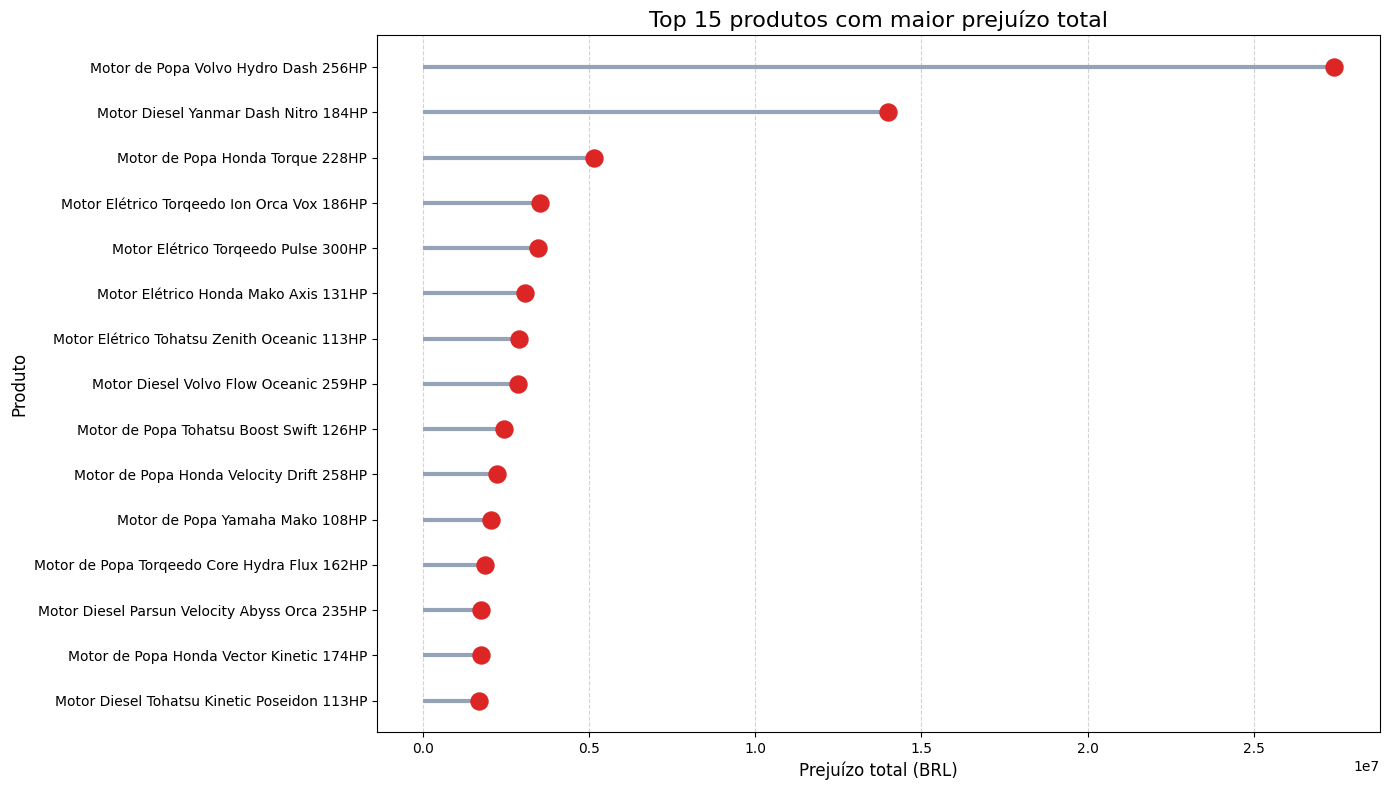

In [62]:
# Parte 2 - Lollipop chart
df_grafico = (
    df_resumo_produtos_sql[df_resumo_produtos_sql['prejuizo_total_brl'] > 0]
    .sort_values('prejuizo_total_brl', ascending=False)
    .head(15)
    .sort_values('prejuizo_total_brl', ascending=True)
)

plt.figure(figsize=(14, 8))

plt.hlines(
    y=df_grafico['product_name'],
    xmin=0,
    xmax=df_grafico['prejuizo_total_brl'],
    color='#94a3b8',
    linewidth=3
)

plt.scatter(
    df_grafico['prejuizo_total_brl'],
    df_grafico['product_name'],
    color='#dc2626',
    s=150,
    zorder=3
)

plt.title('Top 15 produtos com maior prejuízo total', fontsize=16)
plt.xlabel('Prejuízo total (BRL)', fontsize=12)
plt.ylabel('Produto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.25, color='#475569')
plt.tight_layout()
plt.show()


### Parte 3 - Explicação do desenvolvimento

- **Data de câmbio utilizada:** foi utilizada a taxa média de venda do dólar no dia da venda, obtida pela API do Banco Central.
- **Como o prejuízo foi definido:** considerei prejuízo quando o custo total em BRL da transação ficou maior que a receita da transação.
- **Suposições relevantes:** o `usd_price` foi tratado como custo unitário em USD; para cada venda foi usado o último custo disponível com `start_date <= sale_date`; impostos e frete foram ignorados.

-------------------------------------------------------------------------------------------------------------------------


## Capítulo 5 Análise de clientes

In [71]:
import duckdb

con = duckdb.connect()

con.register('df_vendas', df_vendas)
con.register('df_produtos', df_produtos)

In [73]:
# Criando a view de vendas
con.execute("""
CREATE OR REPLACE VIEW vendas_sql AS
SELECT
    id,
    id_client,
    id_product,
    qtd,
    total
FROM df_vendas
""")

# Criando a view de produtos
con.execute("""
CREATE OR REPLACE VIEW produtos_sql AS
SELECT
    code,
    name,
    categoria_padronizada
FROM df_produtos
""")


In [ ]:
# 1. Ticket médio e diversidade de categorias por cliente
query_resumo_clientes = """
WITH base_clientes AS (
    SELECT
        v.id,
        v.id_client,
        v.id_product,
        v.qtd,
        v.total,
        p.categoria_padronizada
    FROM vendas_sql v
    LEFT JOIN produtos_sql p
        ON v.id_product = p.code
)
SELECT
    id_client,
    SUM(total) AS faturamento_total,
    COUNT(id) AS frequencia,
    SUM(total) / COUNT(id) AS ticket_medio,
    COUNT(DISTINCT categoria_padronizada) AS diversidade_categorias
FROM base_clientes
GROUP BY 1
ORDER BY ticket_medio DESC, id_client ASC
"""

df_resumo_clientes_sql = con.execute(query_resumo_clientes).df()
df_resumo_clientes_sql.head()


,id_client,faturamento_total,frequencia,ticket_medio,diversidade_categorias
0,47,64003343.75,190,336859.703947,3
1,42,72187369.50,222,325168.331081,3
2,9,66788855.35,218,306370.896101,3
3,22,59581398.75,198,300916.155303,3
4,2,65652931.35,220,298422.415227,3


In [ ]:
# Top 10 clientes fiéis
query_clientes_fieis = """
WITH base_clientes AS (
    SELECT
        v.id,
        v.id_client,
        v.id_product,
        v.qtd,
        v.total,
        p.categoria_padronizada
    FROM vendas_sql v
    LEFT JOIN produtos_sql p
        ON v.id_product = p.code
),
resumo_clientes AS (
    SELECT
        id_client,
        SUM(total) AS faturamento_total,
        COUNT(id) AS frequencia,
        SUM(total) / COUNT(id) AS ticket_medio,
        COUNT(DISTINCT categoria_padronizada) AS diversidade_categorias
    FROM base_clientes
    GROUP BY 1
)
SELECT
    id_client,
    faturamento_total,
    frequencia,
    ticket_medio,
    diversidade_categorias
FROM resumo_clientes
WHERE diversidade_categorias >= 3
ORDER BY ticket_medio DESC, id_client ASC
LIMIT 10
"""

df_clientes_fieis_sql = con.execute(query_clientes_fieis).df()
df_clientes_fieis_sql


,id_client,faturamento_total,frequencia,ticket_medio,diversidade_categorias
0,47,64003343.75,190,336859.703947,3
1,42,72187369.50,222,325168.331081,3
2,9,66788855.35,218,306370.896101,3
3,22,59581398.75,198,300916.155303,3
4,2,65652931.35,220,298422.415227,3
5,28,60826837.25,204,298170.770833,3
6,46,59126834.35,199,297119.770603,3
7,38,57093331.15,195,292786.313590,3
8,36,62791038.15,215,292051.340233,3
9,5,58592802.70,202,290063.379703,3


In [ ]:
# Categoria mais vendida para os 10 clientes fiéis
query_categoria_top = """
WITH base_clientes AS (
    SELECT
        v.id,
        v.id_client,
        v.id_product,
        v.qtd,
        v.total,
        p.categoria_padronizada
    FROM vendas_sql v
    LEFT JOIN produtos_sql p
        ON v.id_product = p.code
),
resumo_clientes AS (
    SELECT
        id_client,
        SUM(total) AS faturamento_total,
        COUNT(id) AS frequencia,
        SUM(total) / COUNT(id) AS ticket_medio,
        COUNT(DISTINCT categoria_padronizada) AS diversidade_categorias
    FROM base_clientes
    GROUP BY 1
),
clientes_fieis AS (
    SELECT
        id_client
    FROM resumo_clientes
    WHERE diversidade_categorias >= 3
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
)
SELECT
    b.categoria_padronizada,
    SUM(b.qtd) AS quantidade_total_itens
FROM base_clientes b
INNER JOIN clientes_fieis cf
    ON b.id_client = cf.id_client
GROUP BY 1
ORDER BY quantidade_total_itens DESC
"""

df_categoria_top_sql = con.execute(query_categoria_top).df()
df_categoria_top_sql.head(1)


,categoria_padronizada,quantidade_total_itens
0,propulsão,6030.0


In [77]:
categoria_top = df_categoria_top_sql.iloc[0]

print(f"Categoria mais vendida: {categoria_top['categoria_padronizada']}")
print(f"Quantidade total de itens: {categoria_top['quantidade_total_itens']}")

Categoria mais vendida: propulsão
Quantidade total de itens: 6030.0


### Explicação da Questão 5

- As categorias do arquivo `produtos_raw.csv` foram limpas e padronizadas para evitar duplicidade causada por erro de grafia.
- Para cada `id_client`, foram calculados:
  - `faturamento_total`: soma da coluna `total`
  - `frequencia`: contagem de transações
  - `ticket_medio`: faturamento_total / frequencia
  - `diversidade_categorias`: quantidade de categorias distintas compradas
- O ranking final considerou apenas clientes com compras em 3 ou mais categorias distintas.
- Em caso de empate no `ticket_medio`, o desempate foi feito pelo `id_client` em ordem crescente.
- Para os 10 clientes de elite, foi identificada a categoria com maior soma de itens comprados (`qtd`).
 
-------------------------------------------------------------------------------------------------------------------------

## Capítulo 6 - Dimensão de calendário

In [ ]:
# Importando a biblioteca
import duckdb

con = duckdb.connect()
con.register('df_vendas', df_vendas)

In [85]:
# Criando a view de vendas
con.execute("""
CREATE OR REPLACE VIEW vendas_sql AS
SELECT
    id,
    id_client,
    id_product,
    qtd,
    total,
    sale_date::DATE AS sale_date
FROM df_vendas
""")

In [87]:
# Criando o calendário e cruzando com as vendas
query_calendario = """
WITH calendario AS (
    SELECT
        dia::DATE AS data_venda
    FROM generate_series(
        (SELECT MIN(sale_date) FROM vendas_sql),
        (SELECT MAX(sale_date) FROM vendas_sql),
        INTERVAL 1 DAY
    ) AS t(dia)
),
vendas_diarias AS (
    SELECT
        sale_date AS data_venda,
        SUM(total) AS valor_venda
    FROM vendas_sql
    GROUP BY 1
)
SELECT
    c.data_venda,
    CASE EXTRACT(DOW FROM c.data_venda)
        WHEN 0 THEN 'Domingo'
        WHEN 1 THEN 'Segunda-feira'
        WHEN 2 THEN 'Terça-feira'
        WHEN 3 THEN 'Quarta-feira'
        WHEN 4 THEN 'Quinta-feira'
        WHEN 5 THEN 'Sexta-feira'
        WHEN 6 THEN 'Sábado'
    END AS dia_semana,
    COALESCE(v.valor_venda, 0) AS valor_venda
FROM calendario c
LEFT JOIN vendas_diarias v
    ON c.data_venda = v.data_venda
ORDER BY c.data_venda
"""

df_calendario_vendas_sql = con.execute(query_calendario).df()
df_calendario_vendas_sql.head()


,data_venda,dia_semana,valor_venda
0,2023-01-01,Domingo,4207939.25
1,2023-01-02,Segunda-feira,5102799.80
2,2023-01-03,Terça-feira,8299127.05
3,2023-01-04,Quarta-feira,4707759.40
4,2023-01-05,Quinta-feira,5525706.90


In [88]:
# Calculando a média de vendas por dia da semana
query_media_dia_semana = """
WITH calendario AS (
    SELECT
        dia::DATE AS data_venda
    FROM generate_series(
        (SELECT MIN(sale_date) FROM vendas_sql),
        (SELECT MAX(sale_date) FROM vendas_sql),
        INTERVAL 1 DAY
    ) AS t(dia)
),
vendas_diarias AS (
    SELECT
        sale_date AS data_venda,
        SUM(total) AS valor_venda
    FROM vendas_sql
    GROUP BY 1
),
base_final AS (
    SELECT
        c.data_venda,
        CASE EXTRACT(DOW FROM c.data_venda)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana,
        COALESCE(v.valor_venda, 0) AS valor_venda
    FROM calendario c
    LEFT JOIN vendas_diarias v
        ON c.data_venda = v.data_venda
)
SELECT
    dia_semana,
    ROUND(AVG(valor_venda), 2) AS media_vendas
FROM base_final
GROUP BY 1
ORDER BY media_vendas ASC
"""

df_media_dia_semana_sql = con.execute(query_media_dia_semana).df()
df_media_dia_semana_sql

,dia_semana,media_vendas
0,Domingo,3319503.57
1,Segunda-feira,3465137.71
2,Quarta-feira,3535265.63
3,Quinta-feira,3626232.44
4,Terça-feira,3627045.76
5,Sábado,3710540.55
6,Sexta-feira,3715003.41


In [89]:
# Dia da semana com menor média de vendas
df_media_dia_semana_sql.head(1)

,dia_semana,media_vendas
0,Domingo,3319503.57


-------------------------------------------------------------------------------------------------------------------------

## Capítulo 7 - Previsão de demanda

In [1]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Carregando o dataset
df_vendas = pd.read_csv('datasets/vendas_2023_2024.csv')

# Tratamento para leitura das datas
df_vendas['sale_date'] = pd.to_datetime(
    df_vendas['sale_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

df_vendas.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [ ]:
# Filtrando o produto de interesse
id_produto = 54
nome_produto = 'Motor de Popa Yamaha Evo Dash 155HP'

df_produto = df_vendas[df_vendas['id_product'] == id_produto].copy()
df_produto.head()

,id,id_client,id_product,qtd,total,sale_date
46,48,13,54,15,1823022.00,2024-05-30
53,55,35,54,3,346373.80,2024-11-24
71,74,45,54,11,1270038.85,2024-09-25
442,451,42,54,13,1500955.35,2024-02-19
494,503,45,54,11,1270038.85,2024-11-27


In [ ]:
# Criando a série diária de vendas
df_diario = df_produto.groupby('sale_date').agg(
    qtd_vendida=('qtd', 'sum')
).reset_index()

datas = pd.date_range(
    start=df_diario['sale_date'].min(),
    end=df_diario['sale_date'].max(),
    freq='D'
)

df_diario = pd.DataFrame({'sale_date': datas}).merge(
    df_diario,
    on='sale_date',
    how='left'
)

df_diario['qtd_vendida'] = df_diario['qtd_vendida'].fillna(0)

df_diario.head()


,sale_date,qtd_vendida
0,2023-01-10,3.0
1,2023-01-11,0.0
2,2023-01-12,0.0
3,2023-01-13,0.0
4,2023-01-14,0.0


In [4]:
# Separando os dados em treino e teste
treino = df_diario[df_diario['sale_date'] <= '2023-12-31'].copy()
teste = df_diario[
    (df_diario['sale_date'] >= '2024-01-01') &
    (df_diario['sale_date'] <= '2024-01-31')
].copy()

print('Treino:', treino['sale_date'].min(), 'até', treino['sale_date'].max())
print('Teste:', teste['sale_date'].min(), 'até', teste['sale_date'].max())

Treino: 2023-01-10 00:00:00 até 2023-12-31 00:00:00
Teste: 2024-01-01 00:00:00 até 2024-01-31 00:00:00


In [5]:
# Construindo o baseline com média móvel de 7 dias
historico = treino['qtd_vendida'].tolist()
previsoes = []

for valor_real in teste['qtd_vendida']:
    previsao = np.mean(historico[-7:])
    previsoes.append(previsao)
    historico.append(valor_real)

teste['previsao'] = previsoes

teste.head()

,sale_date,qtd_vendida,previsao
356,2024-01-01,0.0,0.0
357,2024-01-02,0.0,0.0
358,2024-01-03,0.0,0.0
359,2024-01-04,0.0,0.0
360,2024-01-05,0.0,0.0


In [ ]:
# Somando a previsão para os primeiros 7 dias de janeiro de 2024
previsao_primeira_semana = teste[
    (teste['sale_date'] >= '2024-01-01') &
    (teste['sale_date'] <= '2024-01-07')
]['previsao'].sum()

round(previsao_primeira_semana)

0

In [6]:
# Avaliando o modelo com MAE
mae = mean_absolute_error(teste['qtd_vendida'], teste['previsao'])
print(f'MAE: {mae:.2f}')

MAE: 1.00


In [7]:
# Comparando valores reais e previstos
teste[['sale_date', 'qtd_vendida', 'previsao']]

,sale_date,qtd_vendida,previsao
356,2024-01-01,0.0,0.000000
357,2024-01-02,0.0,0.000000
358,2024-01-03,0.0,0.000000
359,2024-01-04,0.0,0.000000
360,2024-01-05,0.0,0.000000
361,2024-01-06,0.0,0.000000
362,2024-01-07,0.0,0.000000
363,2024-01-08,0.0,0.000000
364,2024-01-09,0.0,0.000000
365,2024-01-10,0.0,0.000000


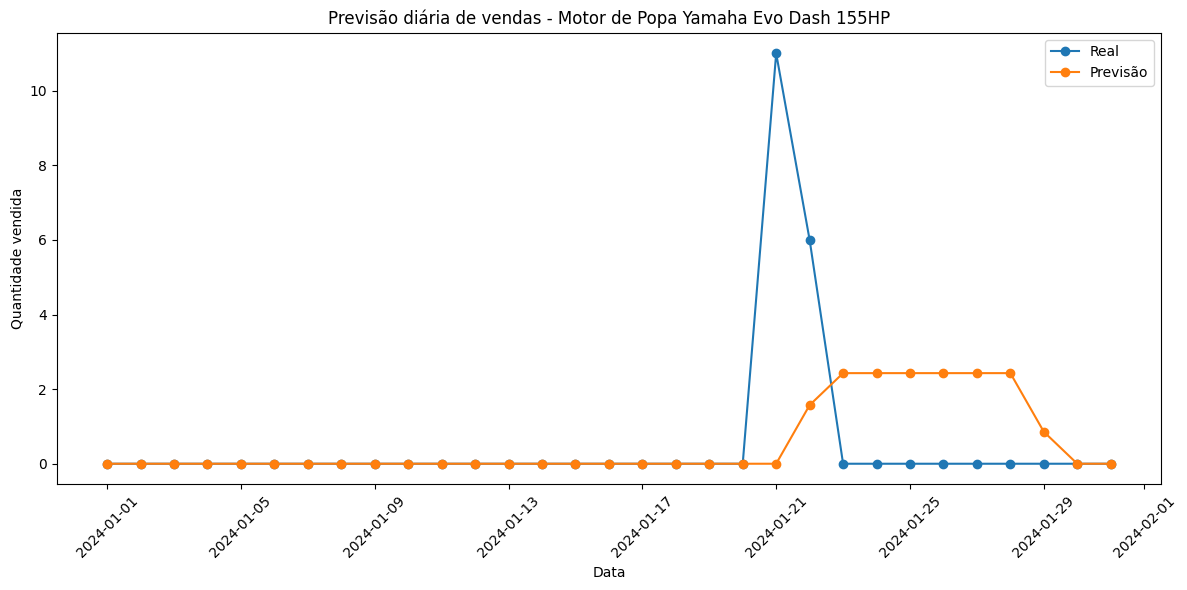

In [ ]:
# Visualizando a previsão
plt.figure(figsize=(12, 6))
plt.plot(teste['sale_date'], teste['qtd_vendida'], label='Real', marker='o')
plt.plot(teste['sale_date'], teste['previsao'], label='Previsão', marker='o')

plt.title(f'Previsão diária de vendas - {nome_produto}')
plt.xlabel('Data')
plt.ylabel('Quantidade vendida')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Resposta objetiva

a. O baseline é adequado para esse produto?
Depende do valor final do MAE e da estabilidade da série. Como baseline, ele serve como referência inicial, mas tende a ser limitado se houver sazonalidade, picos de demanda ou comportamento muito irregular.

b. Cite uma limitação desse método.
A média móvel de 7 dias usa apenas o passado recente e não captura bem tendências, sazonalidade mensal, promoções ou eventos específicos que alterem a demanda.
 
-------------------------------------------------------------------------------------------------------------------------

## Capítulo 8 - Sistema de recomendação

In [10]:
# Importando as bibliotecas
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# Carregando os datasets
df_vendas = pd.read_csv('datasets/vendas_2023_2024.csv')
df_produtos = pd.read_csv('datasets/produtos_raw.csv')

df_produtos.head()

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz


In [11]:
# Identificando o produto de referência
produto_referencia = 'GPS Garmin Vortex Maré Drift'

df_produto_referencia = df_produtos[
    df_produtos['name'] == produto_referencia
][['code', 'name']].drop_duplicates()

df_produto_referencia

,code,name
26,27,GPS Garmin Vortex Maré Drift


In [ ]:
# Criando a matriz usuário-item
df_interacao = df_vendas[['id_client', 'id_product']].drop_duplicates()
df_interacao['comprou'] = 1

matriz_usuario_item = df_interacao.pivot_table(
    index='id_client',
    columns='id_product',
    values='comprou',
    fill_value=0
)

matriz_usuario_item.head()

id_product,1,2,3,4,5,6,7,8,9,10,...,141,142,143,144,145,146,147,148,149,150
id_client,,,,,,,,,,,,,,,,,,,,,
1,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
5,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0


In [13]:
# Calculando a similaridade produto x produto
matriz_item_usuario = matriz_usuario_item.T

similaridade = cosine_similarity(matriz_item_usuario)

df_similaridade = pd.DataFrame(
    similaridade,
    index=matriz_item_usuario.index,
    columns=matriz_item_usuario.index
)

df_similaridade.head()

id_product,1,2,3,4,5,6,7,8,9,10,...,141,142,143,144,145,146,147,148,149,150
id_product,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.775058,0.737865,0.810191,0.748331,0.769484,0.775058,0.727825,0.711512,0.698771,...,0.795133,0.753819,0.775058,0.769484,0.721605,0.775058,0.872082,0.721605,0.727825,0.775058
2,0.775058,1.000000,0.704295,0.757865,0.714286,0.712931,0.771429,0.750290,0.788811,0.687256,...,0.795192,0.778078,0.771429,0.767772,0.685714,0.742857,0.712931,0.628571,0.750290,0.742857
3,0.737865,0.704295,1.000000,0.800641,0.704295,0.865181,0.732467,0.712396,0.777778,0.707107,...,0.675923,0.739795,0.732467,0.757033,0.704295,0.788811,0.729996,0.732467,0.739795,0.704295
4,0.810191,0.757865,0.800641,1.000000,0.757865,0.753310,0.757865,0.789747,0.773953,0.735980,...,0.831239,0.789747,0.730798,0.779287,0.730798,0.730798,0.805263,0.757865,0.763422,0.757865
5,0.748331,0.714286,0.704295,0.757865,1.000000,0.795192,0.742857,0.694713,0.760639,0.627495,...,0.795192,0.722501,0.714286,0.685511,0.685714,0.714286,0.767772,0.657143,0.722501,0.714286


In [14]:
# Gerando o ranking dos 5 produtos mais similares
id_produto_referencia = 27

ranking_similares = df_similaridade[id_produto_referencia].sort_values(ascending=False)

# Removendo o próprio produto da lista
ranking_similares = ranking_similares[ranking_similares.index != id_produto_referencia]

top_5_similares = ranking_similares.head(5).reset_index()
top_5_similares.columns = ['id_product', 'similaridade']

top_5_similares

,id_product,similaridade
0,94,0.869626
1,11,0.868037
2,35,0.853913
3,115,0.850000
4,1,0.850000


In [15]:
# Adicionando os nomes dos produtos ao ranking
top_5_similares = top_5_similares.merge(
    df_produtos[['code', 'name']].drop_duplicates(),
    left_on='id_product',
    right_on='code',
    how='left'
)

top_5_similares[['id_product', 'name', 'similaridade']]

,id_product,name,similaridade
0,94,Motor de Popa Volvo Magnum 276HP,0.869626
1,11,GPS Furuno Swift Leviathan Poseidon,0.868037
2,35,Radar Furuno Swift,0.853913
3,115,Cabo de Nylon Delta Force Magnum Leviathan,0.850000
4,1,Transponder AIS Maré Magnum,0.850000


In [16]:
# Acessando o id do produto mais similar ao GPS Garmin Vortex Maré Drift
top_5_similares.iloc[0]['id_product']

np.int64(94)

### Conclusão

O produto recomendado junto ao item **GPS Garmin Vortex Maré Drift** deve ser aquele que apareceu no topo do ranking de similaridade de cosseno, pois foi o produto com padrão de compra mais parecido entre os clientes.

O ranking final considerou:
- matriz binária de interação cliente x produto
- presença ou ausência de compra
- similaridade produto x produto com cosine similarity
- exclusão do próprio GPS do ranking

-------------------------------------------------------------------------------------------------------------------------